# <center> **Facial Expression Recognition** </center>



Task : Xây dựng một hệ thống nhận diện cảm xúc trên khuôn mặt người , có 7 loại cảm xúc

# Import thư viện

In [1]:
import os
import cv2
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, RocCurveDisplay, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer,LabelEncoder, label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.svm import LinearSVC

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential, save_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from keras.applications import DenseNet121
from sklearn.metrics import roc_curve, auc

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from keras.backend import clear_session
import gc


# Download dataset

## Set up Kaggle API in Colab

Follow these steps to enable Kaggle dataset downloads in your Colab environment:

1.  **Get your Kaggle API Token:**
    *   Go to [Kaggle.com](https://www.kaggle.com/), log in, and navigate to your user profile.
    *   Click on 'Account'.
    *   Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
2.  **Upload `kaggle.json` to Colab:**
    *   Run the code cell below, and a file upload dialog will appear. Upload the `kaggle.json` file you just downloaded.

In [2]:
# Install the Kaggle API client
!pip install -q kaggle
# Create a directory for Kaggle configuration
!mkdir -p ~/.kaggle
# Upload your Kaggle API key (kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pspiecy","key":"c5041866ed4b36bd7e483ff6222b05f1"}'}

In [3]:
# Move the kaggle.json file to the .kaggle directory and set permissions
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Tải dataset từ kaggle

In [4]:
# Download the dataset from Kaggle
!kaggle datasets download shuvoalok/raf-db-dataset
# Unzip the dataset
# The dataset typically gets downloaded as a zip file in the current working directory
!unzip -q raf-db-dataset.zip -d raf-db
print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
  0% 0.00/37.7M [00:00<?, ?B/s]
100% 37.7M/37.7M [00:00<00:00, 1.62GB/s]
Dataset downloaded and unzipped successfully!


# Preprocessing Data

## Thiết lập Nhãn Dữ liệu (Labels)

In [5]:
DATA_DIR = '/content/raf-db/DATASET'
LABELS_DIR = '/content/raf-db'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
TRAIN_LABELS_DIR = os.path.join(LABELS_DIR, 'train_labels.csv')
TEST_LABELS_DIR = os.path.join(LABELS_DIR, 'test_labels.csv')

# Load the labels CSV files
train_labels = pd.read_csv(TRAIN_LABELS_DIR)
test_labels = pd.read_csv(TEST_LABELS_DIR)
# Xem cấu trúc file csv
print(train_labels.head())
print(test_labels.head())

                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5
                   image  label
0  test_0001_aligned.jpg      5
1  test_0002_aligned.jpg      1
2  test_0003_aligned.jpg      4
3  test_0004_aligned.jpg      1
4  test_0005_aligned.jpg      5


### Label MAP

In [6]:
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_map = {label: (idx+1) for idx, label in enumerate(classes)}
print(label_map)

{'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7}


### Tạo 1 hàm để load images và labels từ thư mục

Hàm load_data trả về hai mảng NumPy: mảng hình ảnh (images) và mảng nhãn (labels)

In [7]:
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    for label, idx in tqdm(label_map.items()):
        folder_path = os.path.join(dataset_dir, str(idx))  # +1 because folder names start from '1'
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img_rgb)
            labels.append(idx)

    return np.array(images), np.array(labels)

In [8]:
# Load train and test datasets
train_images, train_labels = load_data(TRAIN_DIR, label_map)
test_images, test_labels = load_data(TEST_DIR, label_map)
print(train_images.shape)
print(test_images.shape)

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

(12271, 100, 100, 3)
(3068, 100, 100, 3)


array([[[ 19,  23,  32],
        [ 20,  24,  33],
        [ 20,  23,  32],
        ...,
        [ 98, 100, 113],
        [104, 106, 119],
        [105, 107, 120]],

       [[ 14,  17,  26],
        [ 16,  19,  26],
        [ 20,  20,  30],
        ...,
        [ 92,  94, 107],
        [ 95,  97, 110],
        [ 94,  96, 109]],

       [[ 17,  16,  24],
        [ 20,  19,  25],
        [ 23,  22,  30],
        ...,
        [ 77,  76,  90],
        [ 81,  80,  94],
        [ 84,  83,  97]],

       ...,

       [[ 50,  36,  27],
        [ 47,  33,  24],
        [ 47,  29,  19],
        ...,
        [106,  73,  54],
        [104,  71,  52],
        [106,  73,  54]],

       [[ 51,  37,  28],
        [ 49,  35,  26],
        [ 49,  31,  21],
        ...,
        [ 92,  59,  40],
        [ 94,  61,  42],
        [102,  69,  50]],

       [[ 53,  39,  30],
        [ 50,  36,  27],
        [ 50,  32,  22],
        ...,
        [106,  73,  54],
        [104,  71,  52],
        [104,  71,  52]]], dtype=uint8)
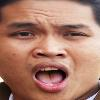

In [9]:
train_images[0]

array([[[ 40,  40,  16],
        [ 11,  11,   0],
        [ 30,  29,   8],
        ...,
        [147, 134,  99],
        [137, 124,  89],
        [111,  98,  63]],

       [[ 22,  22,   0],
        [ 21,  21,   0],
        [ 25,  24,   3],
        ...,
        [123, 110,  75],
        [129, 116,  81],
        [118, 105,  70]],

       [[ 13,  13,   0],
        [ 35,  35,  11],
        [ 21,  20,   0],
        ...,
        [127, 113,  76],
        [142, 128,  91],
        [145, 131,  94]],

       ...,

       [[197, 192, 214],
        [197, 192, 214],
        [190, 182, 203],
        ...,
        [255, 252, 255],
        [255, 252, 255],
        [255, 252, 255]],

       [[147, 142, 164],
        [172, 167, 189],
        [196, 188, 209],
        ...,
        [255, 253, 255],
        [255, 252, 255],
        [254, 251, 255]],

       [[ 65,  60,  82],
        [123, 118, 140],
        [184, 176, 197],
        ...,
        [255, 253, 255],
        [255, 253, 255],
        [255, 253, 255]]], dtype=uint8)
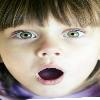

In [10]:
test_images[0]

Tạo hàm show_examples để xem các mẫu từ mỗi lớp cảm xúc

In [11]:
def show_examples(train_images, train_labels, labels, num_examples=5):
    num_classes = len(classes)
    fig, axs = plt.subplots(num_classes, num_examples, figsize=(10, 12))

    for i, class_name in enumerate(classes):
        class_indices = [idx for idx, label in enumerate(train_labels) if label == i+1]
        selected_indices = np.random.choice(class_indices, num_examples, replace=False)
        axs[i, 0].set_title(class_name, fontsize=10, pad=10, fontweight='bold')
        # Display the random images for the current class
        for j, idx in enumerate(selected_indices):
            img = train_images[idx]
            axs[i, j].imshow(img)
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()

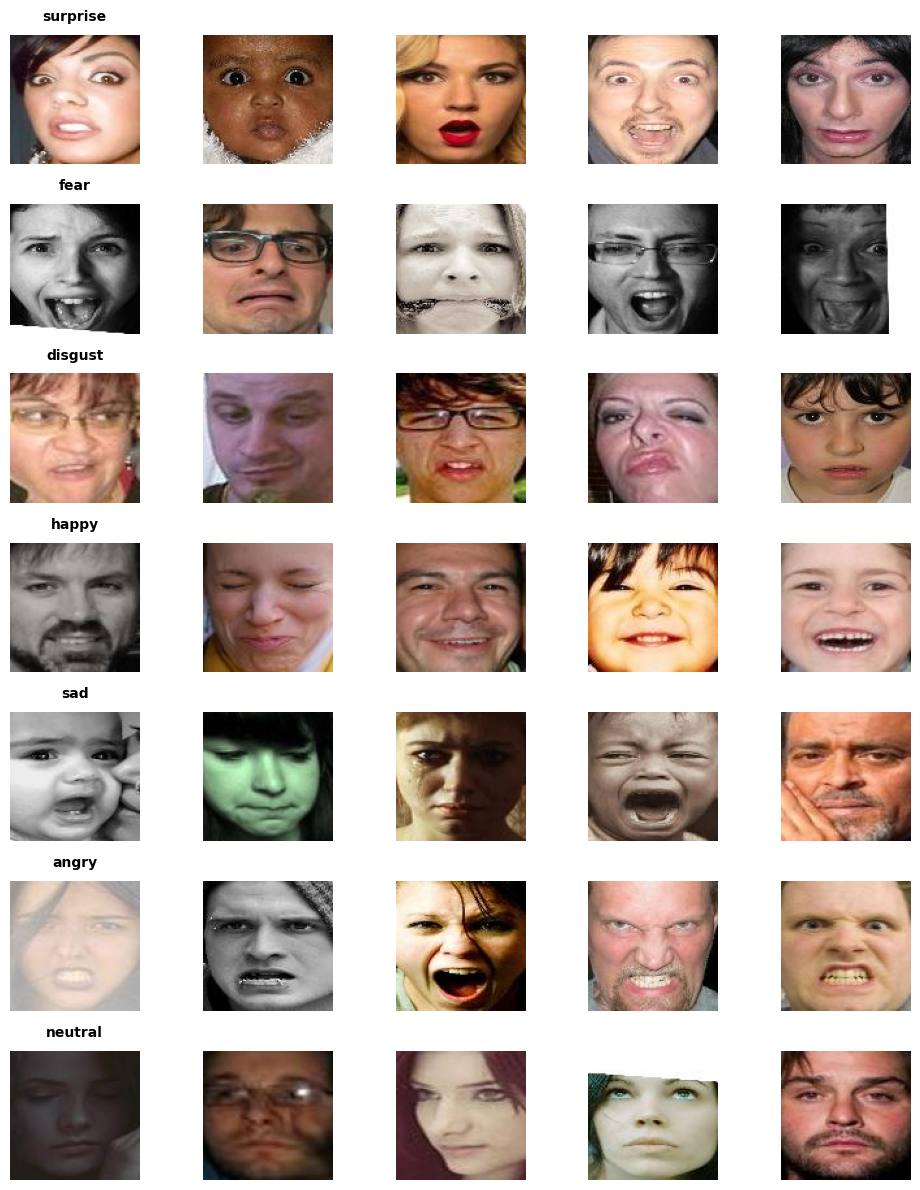

In [12]:
show_examples(train_images, train_labels, classes)

# Prepare data

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 100   # Kích thước ảnh đầu ra mong muốn
BATCH_SIZE = 512

Chuẩn hóa giá trị pixel thành [0,1]

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
)

Tạo hàm reshape ảnh , vì đầu vào EfficientNetB0 là ảnh (224x224) mà ảnh trong bộ dataset là (100x100) nên ta tiến thành reshape ảnh đầu vào cho phù hợp với kiến trúc mô hình

In [15]:
# 2. Train Generator (Tập huấn luyện)
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# 3. Validation Generator (Tập kiểm tra/đánh giá)
validation_generator = validation_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.


In [16]:
print(f"Total ảnh: {train_generator.samples + validation_generator.samples}")
print(f"Ảnh Training: {train_generator.samples}")
print(f"Ảnh Validation: {validation_generator.samples}")
print(f"Số lớp (Emotions): {train_generator.num_classes}")

Total ảnh: 15339
Ảnh Training: 12271
Ảnh Validation: 3068
Số lớp (Emotions): 7


Xử lí mất cân bằng lớp

In [17]:
from sklearn.utils import class_weight
y_classes = train_generator.classes
weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_classes),
    y=y_classes
)
class_weights = dict(enumerate(weights_array))

In [18]:
print("--- Kết quả Tính toán Trọng số Lớp ---")
print("Mapping lớp (Index -> Tên):", train_generator.class_indices)
print("Trọng số Lớp (class_weights):", class_weights)

--- Kết quả Tính toán Trọng số Lớp ---
Mapping lớp (Index -> Tên): {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}
Trọng số Lớp (class_weights): {0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


# XÂY DỰNG MODEL

In [ ]:
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from keras.models import Sequential
from keras.optimizers import Adam
# THÊM DÒNG NÀY:
from keras import regularizers
# HOẶC dùng tf.keras: from tensorflow.keras import regularizers

nb_classes = 7

model= tf.keras.models.Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)))
model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))) 
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))) 
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(512,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
  )
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,036,423 (30.66 MB)

 Trainable params: 8,032,455 (30.64 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [20]:
%%time

# number of epochs to train the NN
epochs = 200

# checkpoint to save best model
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "CNN_Deep3_Augmentation_B.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

callbacks_list = [checkpoint]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.n // validation_generator.batch_size,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1993 - loss: 9.8167
Epoch 1: val_accuracy improved from -inf to 0.46289, saving model to CNN_Deep3_Augmentation_B.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 219s 6s/step - accuracy: 0.2004 - loss: 9.8102 - val_accuracy: 0.4629 - val_loss: 8.9194
Epoch 2/200
 1/23 ━━━━━━━━━━━━━━━━━━━━ 18s 847ms/step - accuracy: 0.2656 - loss: 9.3315

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.46289
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.2656 - loss: 9.3315 - val_accuracy: 0.4629 - val_loss: 8.9128
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2664 - loss: 9.2970
Epoch 3: val_accuracy did not improve from 0.46289
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.2670 - loss: 9.2934 - val_accuracy: 0.4629 - val_loss: 8.7290
Epoch 4/200
 1/23 ━━━━━━━━━━━━━━━━━━━━ 19s 871ms/step - accuracy: 0.3184 - loss: 8.9921
Epoch 4: val_accuracy did not improve from 0.46289
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3184 - loss: 8.9921 - val_accuracy: 0.4629 - val_loss: 8.7189
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3128 - loss: 8.9918
Epoch 5: val_accuracy did not improve from 0.46289
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.3129 - loss: 8.9892 - val_accuracy: 0.1660 - val_loss: 8.6669
Epoch 6/200
 1/23 ━━━━━━━━━━━━━━━━━━━━ 18s 847ms/step - accuracy: 0.3203 - lo

# Đánh giá

In [21]:
import pickle

# 1. Define the filename
filename = 'model_history.pkl'

# 2. Use 'with open(...)' to safely open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    # 3. Dump the history object into the file
    pickle.dump(history.history, file)

print(f"History successfully saved to {filename}")

History successfully saved to model_history.pkl


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Load lại model tốt nhất đã lưu
MODEL_FILENAME = 'CNN_Deep3_Augmentation_B.keras'
best_model = tf.keras.models.load_model(MODEL_FILENAME)

# Tính toán steps cho predict/evaluate
EVAL_STEPS = validation_generator.samples // validation_generator.batch_size + 1
TRAIN_STEPS = train_generator.samples // train_generator.batch_size + 1

# Dự đoán trên tập Validation (Test)
print("Đang dự đoán trên tập Validation/Test...")
validation_generator.reset()
predictions = best_model.predict(validation_generator, steps=EVAL_STEPS, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

# 1. Tính Accuracy & Loss
validation_generator.reset()
test_loss, test_acc = best_model.evaluate(validation_generator, steps=EVAL_STEPS, verbose=0)
train_loss, train_acc = best_model.evaluate(train_generator, steps=TRAIN_STEPS, verbose=0)
print(f"\nĐộ chính xác trên tập Test: {test_acc * 100:.2f}%")
print(f"Tổng tham số: {best_model.count_params():,}")

# 2. Classification Report
class_labels = list(validation_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
print("\nBáo cáo chi tiết:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Đang dự đoán trên tập Validation/Test...
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step

Độ chính xác trên tập Test: 79.79%
Tổng tham số: 8,036,423

Báo cáo chi tiết:
              precision    recall  f1-score   support

           1       0.89      0.74      0.81       329
           2       0.89      0.45      0.59        74
           3       0.43      0.54      0.48       160
           4       0.91      0.93      0.92      1185
           5       0.65      0.91      0.76       478
           6       0.80      0.69      0.74       162
           7       0.82      0.65      0.72       680

    accuracy                           0.80      3068
   macro avg       0.77      0.70      0.72      3068
weighted avg       0.82      0.80      0.80      3068



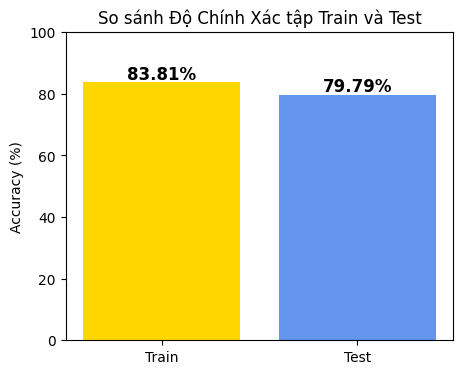

In [23]:
data = {
    'Loại Tập Dữ Liệu': ['Train', 'Test'],
    'Độ Chính Xác (Accuracy)': [train_acc, test_acc]
}
df_acc = pd.DataFrame(data)
# CHÚ Ý: Nhân 100 để chuyển sang dạng phần trăm (0 - 100) cho việc vẽ biểu đồ
accuracies = (df_acc['Độ Chính Xác (Accuracy)'] * 100).tolist()

# 2. Xác định cột có Accuracy cao nhất
best_accuracy = max(accuracies)
best_model_index = accuracies.index(best_accuracy)

colors = ['cornflowerblue', 'cornflowerblue']
colors[best_model_index] = 'gold'

plt.figure(figsize=(5, 4))
bars = plt.bar(df_acc['Loại Tập Dữ Liệu'], accuracies, color=colors)

# Add the percentages above the bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{accuracy:.2f}%',
             ha='center', fontweight='bold', fontsize=12)

plt.ylabel('Accuracy (%)')
plt.title('So sánh Độ Chính Xác tập Train và Test')
plt.ylim([0, 100])

# show graph
plt.show()

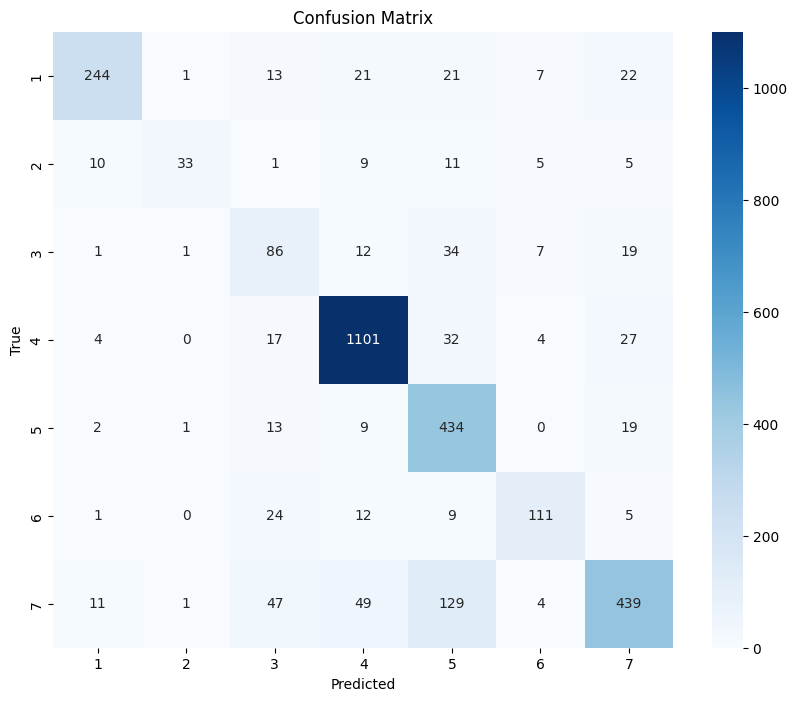

In [24]:
# 3. Confusion Matrix (Hiển thị)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from google.colab import files
files.download('CNN_Deep3_Augmentation_B.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

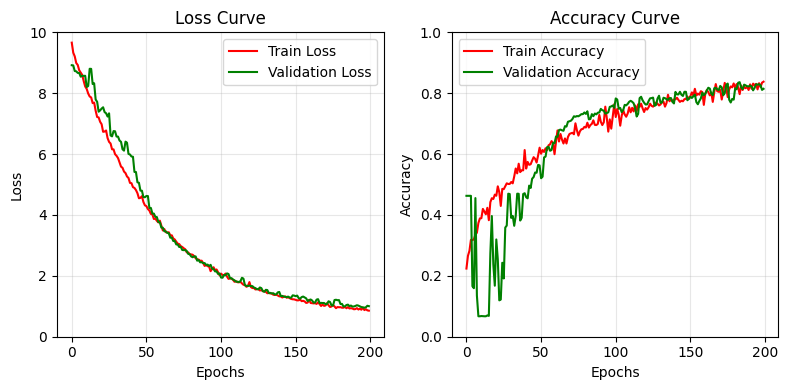

In [26]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(train_loss, label='Train Loss', color='red')
ax[0].plot(val_loss, label='Validation Loss', color='green')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].set_ylim([0, 10])
ax[0].grid(alpha=0.3)

ax[1].plot(train_accuracy, label='Train Accuracy', color='red')
ax[1].plot(val_accuracy, label='Validation Accuracy', color='green')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].set_ylim([0, 1])
ax[1].grid(alpha=0.3)

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()
plt.show()

# Lưu ảnh dự đoán sai (Phân tích lỗi)

In [27]:
import shutil

ERROR_DIR = 'error'
if not os.path.exists(ERROR_DIR):
    # os.makedirs tạo thư mục và mọi thư mục cha cần thiết
    os.makedirs(ERROR_DIR)
    print(f"Thư mục '{ERROR_DIR}' đã được tạo.")


# Đảo ngược mapping để lấy tên nhãn từ index (ví dụ: 0 -> angry)
idx_to_label = {v: k for k, v in validation_generator.class_indices.items()}
errors_idx = np.where(y_true != y_pred)[0]
# Lưu các mẫu sai
for i, idx in enumerate(errors_idx):
    filepath = validation_generator.filepaths[idx]
    true_label_idx = y_true[idx]
    pred_label_idx = y_pred[idx]

    true_label = idx_to_label.get(true_label_idx, str(true_label_idx))
    pred_label = idx_to_label.get(pred_label_idx, str(pred_label_idx))

    # Copy ảnh vào folder error
    filename = os.path.basename(filepath)
    new_filename = f"True_{true_label}_Pred_{pred_label}_{filename}"

    try:
        shutil.copy(filepath, os.path.join(ERROR_DIR, new_filename))
    except FileNotFoundError:
        # Xử lý trường hợp không tìm thấy file, có thể do môi trường khác nhau
        pass

print(f"Đã lưu các mẫu sai vào thư mục '{ERROR_DIR}'.")
print("Vui lòng kiểm tra thư mục này trên hệ thống của bạn.")

Thư mục 'error' đã được tạo.
Đã lưu các mẫu sai vào thư mục 'error'.
Vui lòng kiểm tra thư mục này trên hệ thống của bạn.


In [28]:
!zip -r /content/error.zip /content/error

  adding: content/error/ (stored 0%)
  adding: content/error/True_2_Pred_4_test_2271_aligned.jpg (deflated 5%)
  adding: content/error/True_1_Pred_4_test_1962_aligned.jpg (deflated 7%)
  adding: content/error/True_7_Pred_4_test_2718_aligned.jpg (deflated 7%)
  adding: content/error/True_4_Pred_1_test_0128_aligned.jpg (deflated 4%)
  adding: content/error/True_4_Pred_3_test_0803_aligned.jpg (deflated 6%)
  adding: content/error/True_7_Pred_5_test_2898_aligned.jpg (deflated 6%)
  adding: content/error/True_1_Pred_7_test_1840_aligned.jpg (deflated 5%)
  adding: content/error/True_3_Pred_6_test_2360_aligned.jpg (deflated 6%)
  adding: content/error/True_3_Pred_2_test_1912_aligned.jpg (deflated 7%)
  adding: content/error/True_7_Pred_5_test_2624_aligned.jpg (deflated 5%)
  adding: content/error/True_7_Pred_4_test_3001_aligned.jpg (deflated 6%)
  adding: content/error/True_3_Pred_5_test_2350_aligned.jpg (deflated 5%)
  adding: content/error/True_7_Pred_4_test_2714_aligned.jpg (deflated 6%)
 